In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load dataset
data = pd.read_csv("telecom_mlr_dataset.csv")
data.shape

(106, 10)

In [5]:
# Features and target
features = [
    "bandwidth_mhz",
    "mimo_layers",
    "active_users",
    "prb_util_dl",
    "sinr_db",
    "cqi",
    "packet_loss",
    "latency_ms",
    "weekend"
]
X = data[features]
y = data["throughput_mbps"]
print(X)
print(y)

     bandwidth_mhz  mimo_layers  active_users  prb_util_dl  sinr_db  cqi  \
0               20            4            18           28       24   13   
1               20            4            22           32       23   12   
2               15            4            25           35       21   11   
3               20            2            30           40       20   10   
4               10            2            35           45       18    9   
..             ...          ...           ...          ...      ...  ...   
101             10            2            71           76       13    6   
102             20            4            79           81       13    6   
103             15            2            87           86       11    5   
104             20            4            95           90       10    4   
105             10            2           109           96        8    3   

     packet_loss  latency_ms  weekend  
0           0.10          15        0  
1      

In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [7]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Intercept:", model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.4f}")

print("\nPerformance Metrics")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2 Score:", r2)

# Residuals
residuals = y_test - y_pred

Intercept: -10.031780709878284

Coefficients:
bandwidth_mhz: 0.4569
mimo_layers: 3.7871
active_users: 0.0720
prb_util_dl: -0.1789
sinr_db: 0.5559
cqi: 2.7079
packet_loss: -13.4171
latency_ms: 0.3516
weekend: -1.2104

Performance Metrics
MAE: 1.9617654349620428
MSE: 5.22213067492037
RMSE: 2.2851981697262866
R^2 Score: 0.9728444761272962


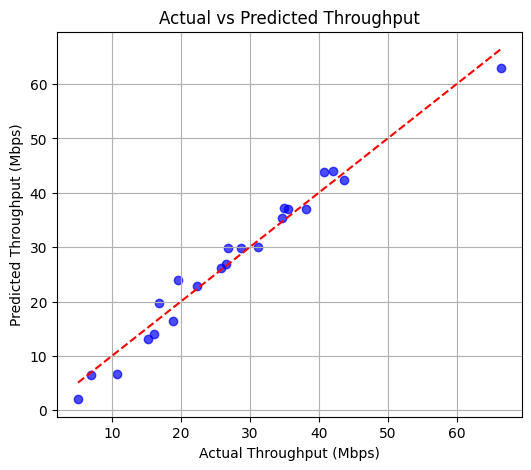

In [8]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color="blue", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Throughput (Mbps)")
plt.ylabel("Predicted Throughput (Mbps)")
plt.title("Actual vs Predicted Throughput")
plt.grid(True)
plt.show()

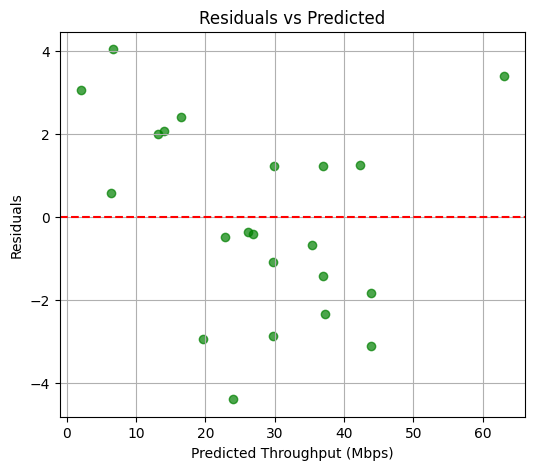

In [9]:
# Plot 2: Residuals vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, color="green", alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Throughput (Mbps)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(True)
plt.show()

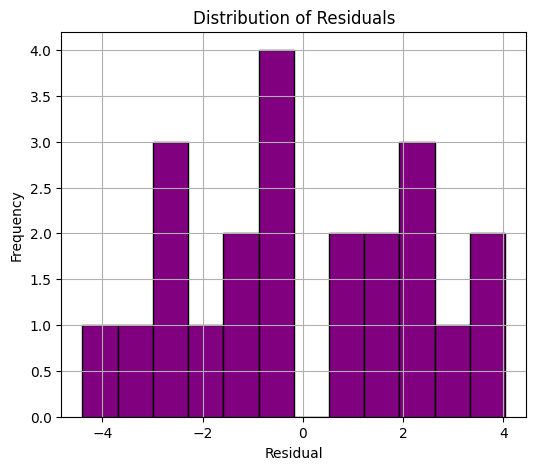

In [12]:
# Plot 3: Histogram of Residuals
plt.figure(figsize=(6, 5))
plt.hist(residuals, bins=12, color="purple", edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()